# 04. SHAP Explainability

In this notebook, we calculate global and local SHAP explanations for our top-performing ML models to identify the top positive/negative contributors for a patient's prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
from xgboost import XGBRegressor, XGBClassifier


In [2]:
# Quick inline prep for self-containment
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

data_dir = '../data'
nhanes_files = ['DEMO_J.xpt', 'GHB_J.xpt', 'GLU_J.xpt', 'BIOPRO_J.xpt', 'BMX_J.xpt', 'DIQ_J.xpt', 'PAQ_J.xpt', 'SMQ_J.xpt']
nhanes_df = None
for file in nhanes_files:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        df = pd.read_sas(file_path)
        nhanes_df = df if nhanes_df is None else pd.merge(nhanes_df, df, on='SEQN', how='outer')

nhanes_df = nhanes_df.dropna(subset=['LBXGH'])
y_nhanes = nhanes_df['LBXGH']
features = ['RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'BMXWAIST', 'LBXGLU', 'PAQ605', 'SMQ020']
X_nhanes = nhanes_df[features].copy()
X_train_nh, X_test_nh, y_train_nh, y_test_nh = train_test_split(X_nhanes, y_nhanes, test_size=0.2, random_state=42)

num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

nhanes_preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'LBXGLU']),
    ('cat', cat_transformer, ['RIAGENDR', 'PAQ605', 'SMQ020'])
])

X_train_nh_prep = nhanes_preprocessor.fit_transform(X_train_nh)
X_test_nh_prep = nhanes_preprocessor.transform(X_test_nh)

feature_names = (['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'LBXGLU'] +
                 list(nhanes_preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['RIAGENDR', 'PAQ605', 'SMQ020'])))

X_train_df = pd.DataFrame(X_train_nh_prep, columns=feature_names)
X_test_df = pd.DataFrame(X_test_nh_prep, columns=feature_names)

### SHAP Global Explanations

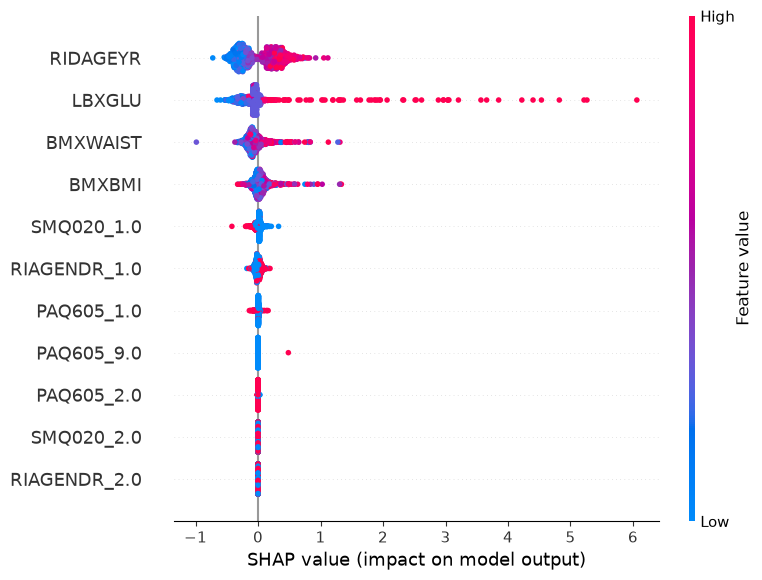

In [3]:
y_train_nh = y_train_nh.fillna(y_train_nh.median())
model = XGBRegressor(n_estimators=50, random_state=42)
model.fit(X_train_df, y_train_nh)

explainer = shap.Explainer(model)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

### SHAP Local Explanations (Patient Level)

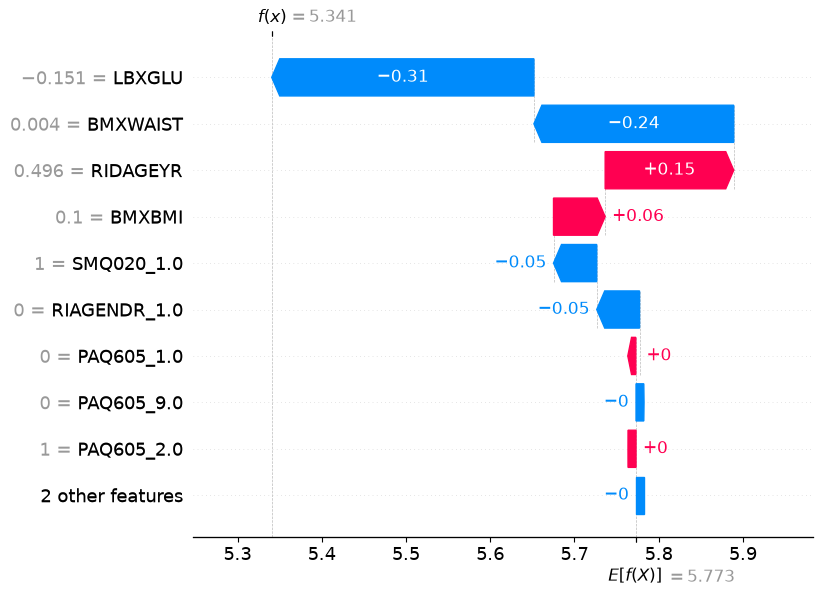

In [4]:
# Explain the first patient in the test set
patient_idx = 0
shap.plots.waterfall(shap_values[patient_idx])